In [15]:
!pip install scikit_learn pandas numpy matplotlib

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error as mse_func
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
import matplotlib.pyplot as plt

Digital Oceans Stocks Prediction

In [17]:
#Importing Dataset
URL = "https://raw.githubusercontent.com/MuhammadMustafa97/Stock_Predictor/refs/heads/main/DigitalOcean%20Holdings%20Stock%20Price%20History.csv"
DO = pd.read_csv(URL)
DO.head()


,Date,Price,Open,High,Low,Vol,Change %
0,12/31/2025,48.12,48.80,48.85,47.93,969.17,-1.39%
1,12/30/2025,48.80,49.24,49.41,48.20,1.20,-1.09%
2,12/29/2025,49.34,48.95,49.50,47.85,1.50,-0.36%
3,12/26/2025,49.52,49.21,49.68,48.91,552.18,0.71%
4,12/24/2025,49.17,48.93,49.68,48.37,510.21,0.49%


In [18]:
#Data Preprocessing
DO['Date'] = pd.to_datetime(DO['Date'])
DO.isnull().sum()


,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol,0
Change %,0


In [19]:
#Feature Selection
X = DO[['Open','High','Low','Vol']]
Y = DO['Price']
#Spliting for test data
X_train_full, X_test, Y_train_full, Y_test = train_test_split(X, Y, test_size=0.2,shuffle=False)

Linear Regression


In [20]:
#Initializing Mean Absolute Error
linear_mae = []
#Initializing Mean Square Error
linear_mse = []
#Initializing Root Mean Square Error
linear_rmse = []
#Initialzing Explained Variance
linear_ev = []

#Initializing for Cross Validation
cross_split = TimeSeriesSplit(n_splits=5)

do_predictions = []
do_ground_truth = []
do_dates = []

for train_index, val_index in cross_split.split(X_train_full):
    X_train = X_train_full.iloc[train_index]
    X_val = X_train_full.iloc[val_index]

    Y_train = Y_train_full.iloc[train_index]
    Y_val = Y_train_full.iloc[val_index]

    Linear_model = LinearRegression()
    Linear_model.fit(X_train, Y_train)

    predictions = Linear_model.predict(X_val)

    do_predictions.extend(predictions)
    do_ground_truth.extend(Y_val.values)
    do_dates.extend(DO.iloc[val_index]['Date'].values)


    linear_mae.append(mean_absolute_error(Y_val, predictions))
    linear_mse.append(mse_func(Y_val, predictions))
    linear_rmse.append(r2_score(Y_val, predictions))
    linear_ev.append(explained_variance_score(Y_val, predictions))

print("Average MAE:", np.mean(linear_mae))
print("Average MSE:", np.mean(linear_mse))
print("Average RMSE:", np.mean(linear_rmse))
print("Average EV:", np.mean(linear_ev))


Average MAE: 0.4002966239797492
Average MSE: 0.2936993611514236
Average RMSE: 0.9877506416252938
Average EV: 0.9877847610679339


In [21]:
comparison_DO = pd.DataFrame({
    'Predicted ': do_predictions,
    ' Ground Truth': do_ground_truth
})

comparison_DO.head()

,Predicted,Ground Truth
0,28.407458,28.62
1,28.693195,28.25
2,32.848671,32.76
3,32.468233,32.56
4,31.935963,31.48


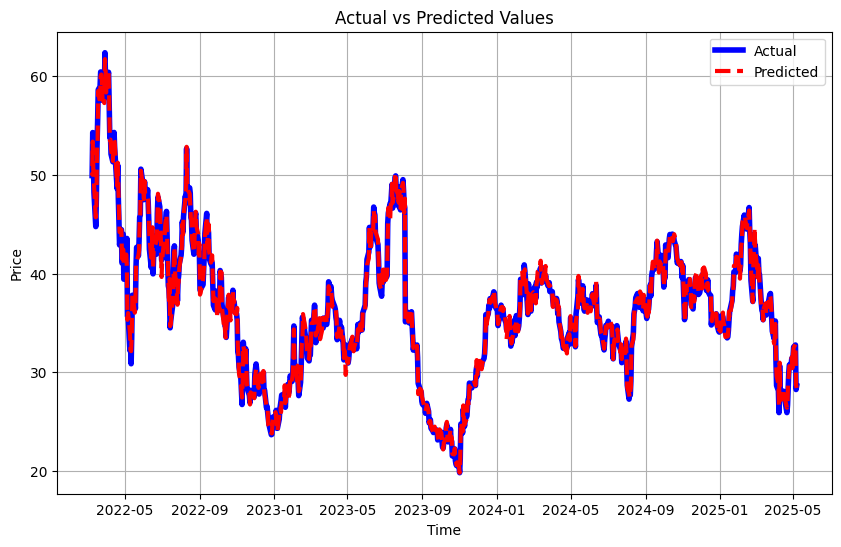

In [22]:
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(do_dates, do_ground_truth, label="Actual", color="blue", linewidth=4)

# Plot predicted values
plt.plot(do_dates, do_predictions, label="Predicted", color="red", linestyle="--", linewidth=3)

plt.title("Actual vs Predicted Values")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()


Decision Tree Regressor

In [23]:
#Initializing Mean Absolute Error
tree_mae = []
#Initializing Mean Square Error
tree_mse = []
#Initializing Root Mean Square Error
tree_rmse = []
#Initialzing Explained Variance
tree_ev = []

#Initializing for Cross Validation
cross_split = TimeSeriesSplit(n_splits=5)

do_predictions = []
do_ground_truth = []
do_dates = []
for train_index, val_index in cross_split.split(X_train_full):
    X_train = X_train_full.iloc[train_index]
    X_val = X_train_full.iloc[val_index]

    Y_train = Y_train_full.iloc[train_index]
    Y_val = Y_train_full.iloc[val_index]

    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, Y_train)

    predictions = model.predict(X_val)

    do_predictions.extend(predictions)
    do_ground_truth.extend(Y_val.values)
    do_dates.extend(DO.iloc[val_index]['Date'].values)

    tree_mae.append(mean_absolute_error(Y_val, predictions))
    tree_mse.append(mse_func(Y_val, predictions))
    tree_rmse.append(r2_score(Y_val, predictions))
    tree_ev.append(explained_variance_score(Y_val, predictions))

print("Average MAE:", np.mean(tree_mae))
print("Average MSE:", np.mean(tree_mse))
print("Average RMSE:", np.mean(tree_rmse))
print("Average EV:", np.mean(tree_ev))

Average MAE: 0.9042138364779874
Average MSE: 2.338290691823899
Average RMSE: 0.9363728766984764
Average EV: 0.9413142319045479


In [24]:
comparison_DO = pd.DataFrame({
    'Predicted ': do_predictions,
    ' Ground Truth': do_ground_truth
})

comparison_DO.head()

,Predicted,Ground Truth
0,27.86,28.62
1,30.05,28.25
2,32.36,32.76
3,32.04,32.56
4,31.87,31.48


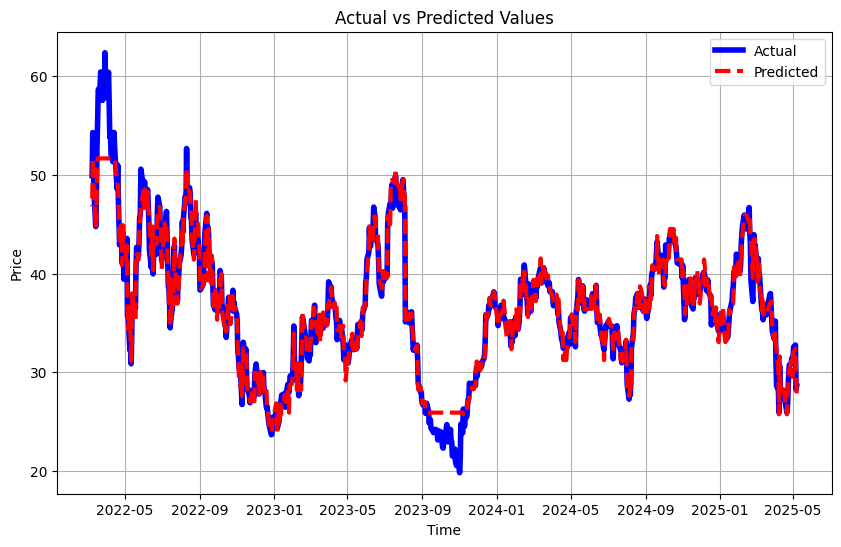

In [25]:
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(do_dates, do_ground_truth, label="Actual", color="blue", linewidth=4)

# Plot predicted values
plt.plot(do_dates, do_predictions, label="Predicted", color="red", linestyle="--", linewidth=3)

plt.title("Actual vs Predicted Values")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()


Random Forest

In [26]:
#Initializing Mean Absolute Error
forest_mae = []
#Initializing Mean Square Error
forest_mse = []
#Initializing Root Mean Square Error
forest_rmse = []
#Initialzing Explained Variance
forest_ev = []

#Initializing for Cross Validation
cross_split = TimeSeriesSplit(n_splits=5)

do_predictions = []
do_ground_truth = []
do_dates = []

for train_index, val_index in cross_split.split(X_train_full):
    X_train = X_train_full.iloc[train_index]
    X_val = X_train_full.iloc[val_index]

    Y_train = Y_train_full.iloc[train_index]
    Y_val = Y_train_full.iloc[val_index]

    model = RandomForestRegressor(n_estimators=200, random_state=40)
    model.fit(X_train, Y_train)

    predictions = model.predict(X_val)

    do_predictions.extend(predictions)
    do_ground_truth.extend(Y_val.values)
    do_dates.extend(DO.iloc[val_index]['Date'].values)

    forest_mae.append(mean_absolute_error(Y_val, predictions))
    forest_mse.append(mse_func(Y_val, predictions))
    forest_rmse.append(r2_score(Y_val, predictions))
    forest_ev.append(explained_variance_score(Y_val, predictions))

print("Average MAE:", np.mean(forest_mae))
print("Average MSE:", np.mean(forest_mse))
print("Average RMSE:", np.mean(forest_rmse))
print("Average EV:", np.mean(forest_ev))

Average MAE: 0.8194455974842739
Average MSE: 2.353141367600618
Average RMSE: 0.9442722143433915
Average EV: 0.9495263917792496


In [27]:
comparison_DO = pd.DataFrame({
    'Predicted ': do_predictions,
    ' Ground Truth': do_ground_truth
})

comparison_DO.head()

,Predicted,Ground Truth
0,28.04185,28.62
1,29.21405,28.25
2,32.54100,32.76
3,32.16500,32.56
4,31.91950,31.48


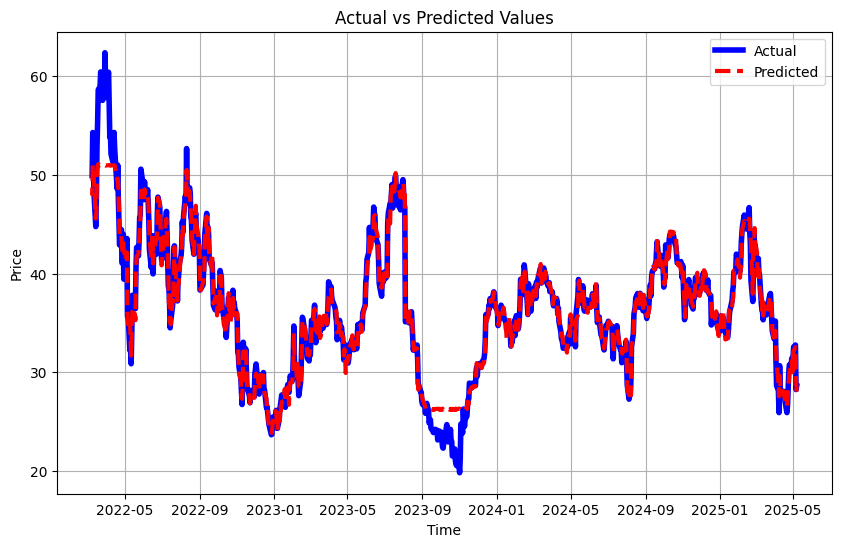

In [28]:
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(do_dates, do_ground_truth, label="Actual", color="blue", linewidth=4)

# Plot predicted values
plt.plot(do_dates, do_predictions, label="Predicted", color="red", linestyle="--", linewidth=3)

plt.title("Actual vs Predicted Values")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()


Predicting Stocks for January 2026 using Random Forest

In [29]:
# Moving the "Price" column one step left to create the target
DO['Predicted Close'] = DO['Price'].shift(-1)

# Drop last row
DO = DO.dropna()

# Features and target
X = DO[['Open', 'High', 'Low', 'Vol']]
Y = DO['Predicted Close']

# Initializing Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

# Training the model
rf_model.fit(X, Y)

# Preparing the last known data point
last_known_features = X.iloc[[-1]]

# Predicting for January 2026
future_price = rf_model.predict(last_known_features)

print("Prediction for January 2026 (Random Forest):", future_price[0])

Prediction for January 2026 (Random Forest): 42.02290000000013
